# House Prices

##  Import & nạp dữ liệu

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

train = pd.read_csv('Data/train.csv')
test  = pd.read_csv('Data/test.csv')

train_raw = train.copy()
test_raw  = test.copy()

print('Train:', train.shape, '| Test:', test.shape)

Train: (1460, 81) | Test: (1459, 80)


# House Prices

## 0. Import & nạp dữ liệu

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

train = pd.read_csv('Data/train.csv')
test  = pd.read_csv('Data/test.csv')

train_raw = train.copy()
test_raw  = test.copy()

print('Train:', train.shape, '| Test:', test.shape)

Train: (1460, 81) | Test: (1459, 80)


## 1. Phân loại biến

In [104]:
ID_COL = 'Id'
TARGET = 'SalePrice'

discrete_cols = [
    'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MoSold', 'YrSold',
    'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',
]

continuous_cols = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
    'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
    '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', TARGET,
]

ordinal_cols = [
    'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual',
    'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'LotShape',
    'LandSlope', 'Utilities', 'Functional', 'GarageFinish', 'PavedDrive',
]

assigned = {ID_COL, *discrete_cols, *continuous_cols, *ordinal_cols}
nominal_cols = [c for c in train.columns if c not in assigned]

groups = {
    'Số – rời rạc': discrete_cols,
    'Số – liên tục': continuous_cols,
    'Phân loại – thứ tự': ordinal_cols,
    'Phân loại – danh nghĩa': nominal_cols,
}

all_assigned = [ID_COL] + discrete_cols + continuous_cols + ordinal_cols + nominal_cols
assert len(all_assigned) == len(set(all_assigned)), 'Có cột bị gán trùng nhóm'
assert set(all_assigned) == set(train.columns), 'Có cột chưa được phân nhóm'

col2group = {ID_COL: 'Định danh (Id)'}
for g, cols in groups.items():
    for c in cols:
        col2group[c] = g

for g, cols in groups.items():
    print(f'\n[{g}] ({len(cols)} cột):\n  ', ', '.join(cols))


[Số – rời rạc] (14 cột):
   YearBuilt, YearRemodAdd, GarageYrBlt, MoSold, YrSold, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, TotRmsAbvGrd, Fireplaces, GarageCars

[Số – liên tục] (20 cột):
   LotFrontage, LotArea, MasVnrArea, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, GarageArea, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, MiscVal, SalePrice

[Phân loại – thứ tự] (22 cột):
   OverallQual, OverallCond, ExterQual, ExterCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, HeatingQC, KitchenQual, FireplaceQu, GarageQual, GarageCond, PoolQC, Fence, LotShape, LandSlope, Utilities, Functional, GarageFinish, PavedDrive

[Phân loại – danh nghĩa] (24 cột):
   MSSubClass, MSZoning, Street, Alley, LandContour, LotConfig, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, Foundation, Heating, CentralAir, 

## 2. Báo cáo tỷ lệ dữ liệu khuyết

In [105]:
def missing_report(df, name):
    n = len(df)
    rep = pd.DataFrame({'Số dòng khuyết': df.isnull().sum()})
    rep['Tỷ lệ khuyết (%)'] = (rep['Số dòng khuyết'] / n * 100).round(2)
    rep = rep[rep['Số dòng khuyết'] > 0].sort_values('Tỷ lệ khuyết (%)', ascending=False)
    total = df.size
    print(f'[{name}] {len(rep)}/{df.shape[1]} cột có khuyết | '
          f'{int(df.isnull().sum().sum())} ô khuyết ({df.isnull().sum().sum()/total*100:.2f}% tổng số ô)')
    return rep

report_train = missing_report(train_raw, 'TRAIN')

[TRAIN] 19/81 cột có khuyết | 7829 ô khuyết (6.62% tổng số ô)


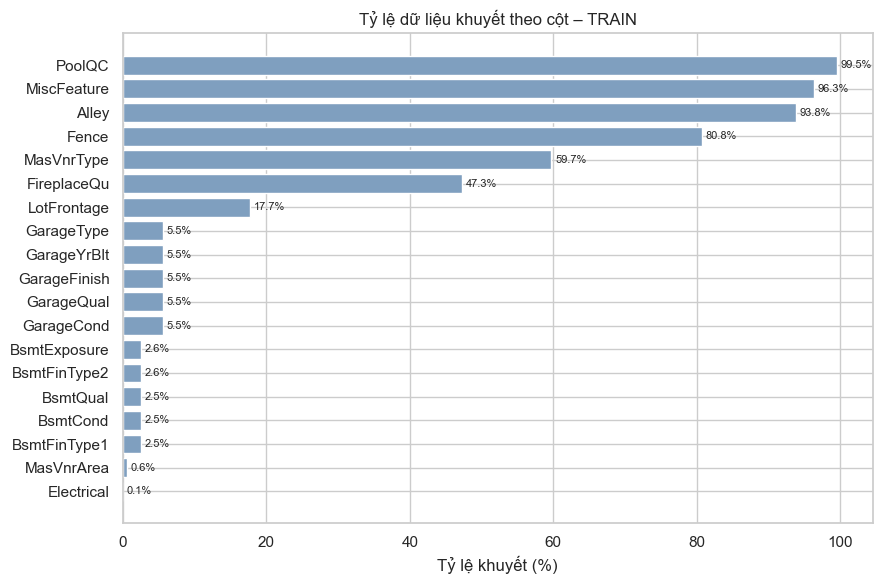

In [106]:
KEY = ['PoolQC', 'Alley', 'Fence', 'FireplaceQu']

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = report_train.reset_index().rename(columns={'index': 'Cột'})
ax.barh(plot_df['Cột'], plot_df['Tỷ lệ khuyết (%)'], color='#7f9fbf')
ax.invert_yaxis()
ax.set_xlabel('Tỷ lệ khuyết (%)')
ax.set_title('Tỷ lệ dữ liệu khuyết theo cột – TRAIN')
for i, v in enumerate(plot_df['Tỷ lệ khuyết (%)']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()

In [107]:
report_test = missing_report(test_raw, 'TEST')

[TEST] 33/80 cột có khuyết | 7878 ô khuyết (6.75% tổng số ô)


## 3. Điền khuyết

In [108]:
STRUCTURES = {
    'Hồ bơi': (['PoolQC'], ['PoolArea'],
               lambda d: d['PoolArea'].fillna(0) > 0),
    'Tầng hầm': (['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'],
                 ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'],
                 lambda d: d['TotalBsmtSF'].fillna(0) > 0),
    'Gara': (['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'],
             ['GarageCars', 'GarageArea', 'GarageYrBlt'],
             lambda d: d['GarageType'].notna() | (d['GarageArea'].fillna(0) > 0)),
    'Lò sưởi': (['FireplaceQu'], [],
                lambda d: d['Fireplaces'].fillna(0) > 0),
    'Ốp gạch/đá': ([], ['MasVnrArea'],
                   lambda d: d['MasVnrArea'].fillna(0) > 0),
    'Tiện ích khác': (['MiscFeature'], [],
                      lambda d: d['MiscVal'].fillna(0) > 0),
}

ALWAYS_NONE = ['Alley', 'Fence', 'MasVnrType']

def fit_fill_values(ref):
    vals = {}
    for name, (cat, num, has) in STRUCTURES.items():
        mask = has(ref)
        for c in cat:
            s = ref.loc[mask, c].dropna()
            vals[c] = s.mode()[0] if len(s) else 'None'
        for c in num:
            s = ref.loc[mask, c].dropna()
            vals[c] = s.median() if len(s) else 0
    return vals

fill_values = fit_fill_values(train_raw)

def impute_structural(df):
    df = df.copy()
    masks = {name: has(df) for name, (_, _, has) in STRUCTURES.items()}
    for name, (cat, num, _) in STRUCTURES.items():
        present = masks[name]
        for c in cat:
            na = df[c].isna()
            df.loc[na & ~present, c] = 'None'
            df.loc[na & present, c] = fill_values[c]
        for c in num:
            na = df[c].isna()
            df.loc[na & ~present, c] = 0
            if c == 'GarageYrBlt':
                df.loc[na & present, c] = df.loc[na & present, 'YearBuilt']
            else:
                df.loc[na & present, c] = fill_values[c]
    for c in ALWAYS_NONE:
        df[c] = df[c].fillna('None')
    return df

train = impute_structural(train)
test = impute_structural(test)

### Khuyết ngẫu nhiên còn lại

In [109]:
RANDOM_CAT = ['Electrical', 'MSZoning', 'Utilities', 'Functional', 'Exterior1st',
              'Exterior2nd', 'KitchenQual', 'SaleType']

for c in RANDOM_CAT:
    mode_val = train_raw[c].mode()[0]
    for d in (train, test):
        d[c] = d[c].fillna(mode_val)

for d, nm in ((train, 'train'), (test, 'test')):
    for c in d.columns:
        if c in ('LotFrontage', TARGET) or not d[c].isna().any():
            continue
        fill = train_raw[c].median() if pd.api.types.is_numeric_dtype(d[c]) else train_raw[c].mode()[0]
        print(f'[safety-net] {nm}.{c}: {d[c].isna().sum()} ô → {fill}')
        d[c] = d[c].fillna(fill)

print('Còn khuyết sau bước này:')
print('  train:', train.drop(columns='LotFrontage').isna().sum().sum(),
      '| test:', test.drop(columns='LotFrontage').isna().sum().sum())

Còn khuyết sau bước này:
  train: 0 | test: 0


## 4. Nội suy LotFrontage theo Neighborhood

In [110]:
lf_median_by_nb = train_raw.groupby('Neighborhood')['LotFrontage'].median()
lf_global_median = train_raw['LotFrontage'].median()

def impute_lotfrontage(df):
    df = df.copy()
    before = int(df['LotFrontage'].isna().sum())
    df['LotFrontage'] = df['LotFrontage'].fillna(df['Neighborhood'].map(lf_median_by_nb))
    fallback = int(df['LotFrontage'].isna().sum())
    df['LotFrontage'] = df['LotFrontage'].fillna(lf_global_median)
    print(f'  khuyết ban đầu: {before} | điền theo Neighborhood: {before - fallback} | '
          f'dự phòng bằng median toàn cục: {fallback}')
    return df

print('TRAIN'); train = impute_lotfrontage(train)
print('TEST');  test  = impute_lotfrontage(test)

print(f"\nLotFrontage train – trước: mean={train_raw['LotFrontage'].mean():.2f}, "
      f"median={train_raw['LotFrontage'].median():.2f} | sau: mean={train['LotFrontage'].mean():.2f}, "
      f"median={train['LotFrontage'].median():.2f}")

TRAIN
  khuyết ban đầu: 259 | điền theo Neighborhood: 259 | dự phòng bằng median toàn cục: 0
TEST
  khuyết ban đầu: 227 | điền theo Neighborhood: 227 | dự phòng bằng median toàn cục: 0

LotFrontage train – trước: mean=70.05, median=69.00 | sau: mean=70.20, median=70.00


## 5. Kiểm tra đầu ra

In [111]:
na_train, na_test = int(train.isna().sum().sum()), int(test.isna().sum().sum())
print(f'NaN train: {na_train} | NaN test: {na_test}')
print(f'Shape train: {train.shape} | test: {test.shape}')
assert na_train == 0 and na_test == 0
assert train.shape == train_raw.shape and test.shape == test_raw.shape
assert (train['Id'].values == train_raw['Id'].values).all()

NaN train: 0 | NaN test: 0
Shape train: (1460, 81) | test: (1459, 80)


In [112]:
train.to_csv('Data/train_filled.csv', index=False)
test.to_csv('Data/test_filled.csv', index=False)

chk_tr = pd.read_csv('Data/train_filled.csv', keep_default_na=False, na_values=[''])
chk_te = pd.read_csv('Data/test_filled.csv',  keep_default_na=False, na_values=[''])
print('Nạp lại → NaN train:', chk_tr.isna().sum().sum(), '| NaN test:', chk_te.isna().sum().sum())

Nạp lại → NaN train: 0 | NaN test: 0


## 6. Feature Engineering

In [113]:
train_fe, test_fe = train.copy(), test.copy()

def add_features(d):
    d['TotalSF']      = d['TotalBsmtSF'] + d['1stFlrSF'] + d['2ndFlrSF']
    d['HouseAge']     = d['YrSold'] - d['YearBuilt']
    d['RemodAge']     = d['YrSold'] - d['YearRemodAdd']
    d['TotalBath']    = d['FullBath'] + 0.5 * d['HalfBath'] + d['BsmtFullBath'] + 0.5 * d['BsmtHalfBath']
    d['HasGarage']    = (d['GarageArea'] > 0).astype(int)
    d['HasBsmt']      = (d['TotalBsmtSF'] > 0).astype(int)
    d['HasFireplace'] = (d['Fireplaces'] > 0).astype(int)
    d['Has2ndFloor']  = (d['2ndFlrSF'] > 0).astype(int)
    d['TotalPorchSF'] = (d['OpenPorchSF'] + d['3SsnPorch'] + d['EnclosedPorch']
                         + d['ScreenPorch'] + d['WoodDeckSF'])
    return d

train_fe, test_fe = add_features(train_fe), add_features(test_fe)

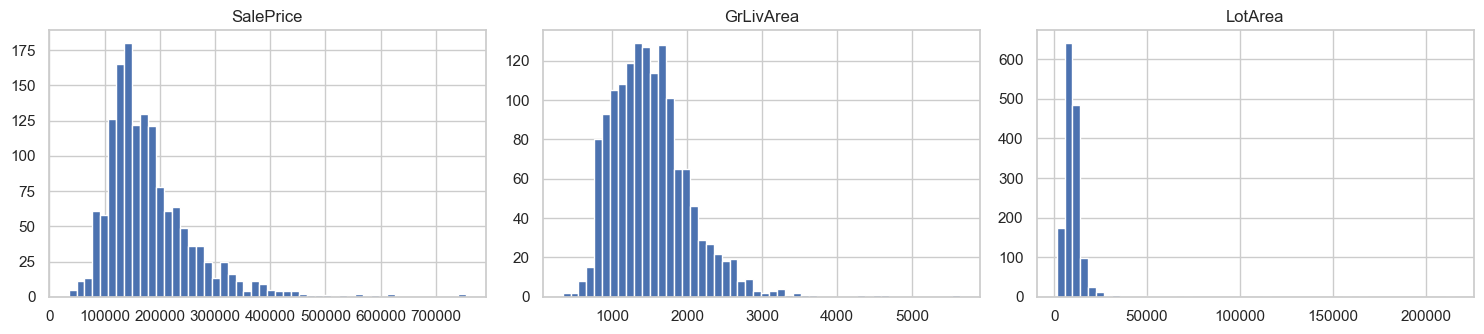

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, ['SalePrice', 'GrLivArea', 'LotArea']):
    train_fe[col].hist(bins=50, ax=ax); ax.set_title(col)
plt.tight_layout(); plt.show()

In [115]:
log_features = ['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'BsmtFinSF2',
                'ScreenPorch', 'EnclosedPorch', 'MasVnrArea', 'LotFrontage', 'OpenPorchSF',
                'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'TotalSF']

for col in log_features:
    train_fe[col] = np.log1p(train_fe[col])
    test_fe[col]  = np.log1p(test_fe[col])

In [116]:
print('Cột chỉ có ở train:', set(train_fe.columns) - set(test_fe.columns))
print('Cột chỉ có ở test :', set(test_fe.columns) - set(train_fe.columns))
print('Train shape:', train_fe.shape, '| Test shape:', test_fe.shape)
print('NaN train_fe:', train_fe.isna().sum().sum(), '| NaN test_fe:', test_fe.isna().sum().sum())
assert train_fe.isna().sum().sum() == 0 and test_fe.isna().sum().sum() == 0

train_fe.to_csv('Data/train_fe.csv', index=False)
test_fe.to_csv('Data/test_fe.csv', index=False)

Cột chỉ có ở train: {'SalePrice'}
Cột chỉ có ở test : set()
Train shape: (1460, 90) | Test shape: (1459, 89)
NaN train_fe: 0 | NaN test_fe: 0


# Phân tích đa biến và chẩn đoán đa cộng tuyến (Ames Housing)

**Nhiệm vụ**
- Xây dựng ma trận tương quan Pearson giữa các biến số và `SalePrice`, xếp hạng yếu tố có sức dự báo mạnh nhất.
- Với biến phân loại: dùng boxplot và ANOVA (kèm eta²) để đo mức ảnh hưởng, lấy `Neighborhood` làm ví dụ chính.
- Phát hiện các "cặp biến song sinh" (tương quan chặt giữa các biến độc lập).
- Tính VIF, xác định biến dư thừa, đề xuất danh sách biến loại bỏ.

**Đầu ra**: bảng xếp hạng tương quan, các biểu đồ, bảng VIF trước và sau xử lý, danh sách biến cần loại (`features_to_drop.csv`, `vif_before.csv`, `vif_after.csv`).

**Đầu vào hiện tại**: `train.csv` của Kaggle (1460 dòng, 81 cột)

In [117]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
%matplotlib inline
sns.set_theme(style='whitegrid')

df = pd.read_csv('Data/train.csv')

# --- Điền khuyết rút gọn ---
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu','GarageType','GarageFinish',
             'GarageQual','GarageCond','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
             'BsmtFinType2','MasVnrType']
for c in none_cols: df[c] = df[c].fillna('None')
for c in ['GarageYrBlt','MasVnrArea']: df[c] = df[c].fillna(0)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda s: s.fillna(s.median()))
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
print(df.shape, '| NaN còn lại:', df.isna().sum().sum())

(1460, 81) | NaN còn lại: 0


## 1. Tương quan Pearson với SalePrice

`MSSubClass` là mã loại nhà (10, 20, 30, ...) nên thực chất là biến danh nghĩa, được tách ra khỏi nhóm biến số. `Id` chỉ là chỉ số dòng nên bỏ.

OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507


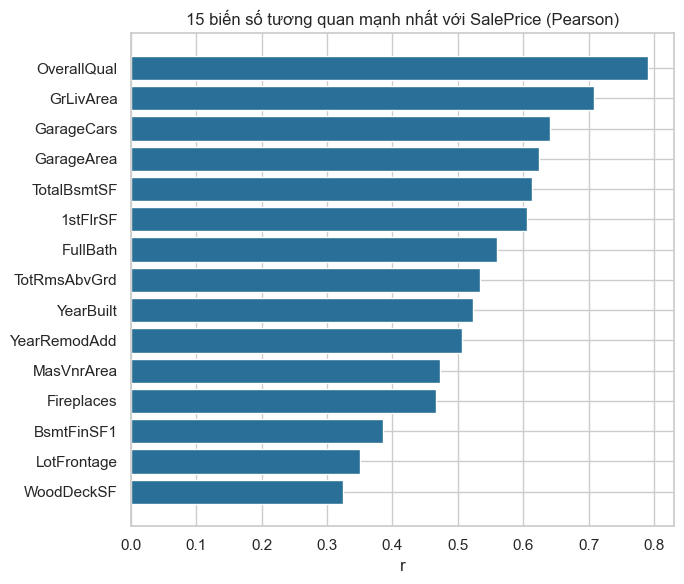

In [118]:
num = df.select_dtypes('number').drop(columns=['Id','MSSubClass'])
corr_target = num.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print(corr_target.head(10).round(3).to_string())

fig, ax = plt.subplots(figsize=(7,6))
top = corr_target.head(15)[::-1]
ax.barh(top.index, top.values, color='#2a6f97')
ax.set_title('15 biến số tương quan mạnh nhất với SalePrice (Pearson)')
ax.set_xlabel('r'); plt.tight_layout(); plt.show()

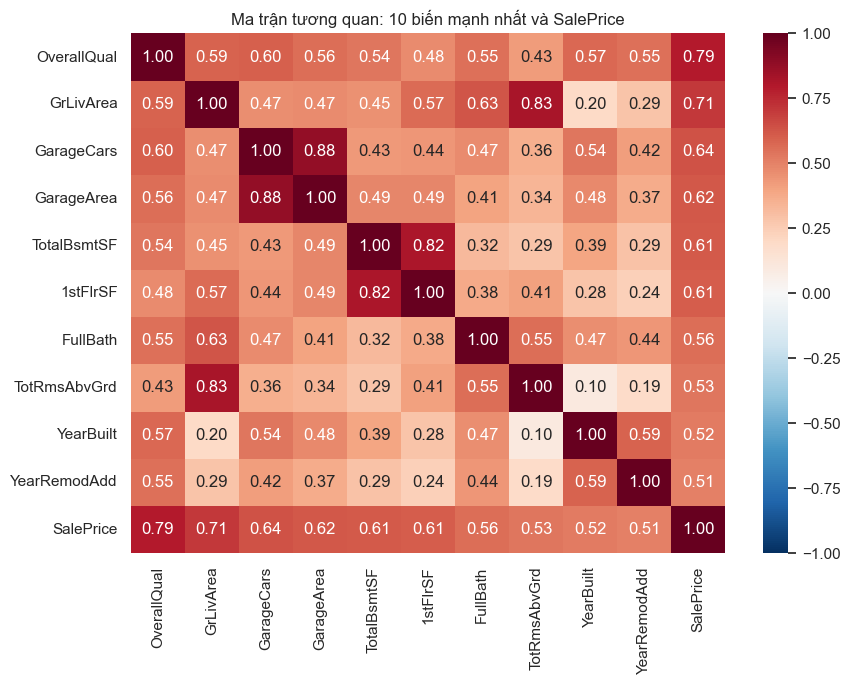

In [119]:
top10 = corr_target.head(10).index.tolist() + ['SalePrice']
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(num[top10].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Ma trận tương quan: 10 biến mạnh nhất và SalePrice')
plt.tight_layout(); plt.show()

**Nhận xét**: `OverallQual` dẫn đầu (r ≈ 0.79), sau đó là các biến diện tích và gara: `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62), `TotalBsmtSF` (0.61). Các số này khớp với phần 5 của báo cáo. Trong heatmap cũng thấy ngay các ô đậm giữa những biến độc lập với nhau (gara, tầng hầm, diện tích sống), đó là dấu hiệu đa cộng tuyến cần kiểm tra ở mục 3.

## 2. Các cặp biến độc lập tương quan chặt

        bien_1        bien_2      r
0   GarageCars    GarageArea  0.882
1    GrLivArea  TotRmsAbvGrd  0.825
2  TotalBsmtSF      1stFlrSF  0.820


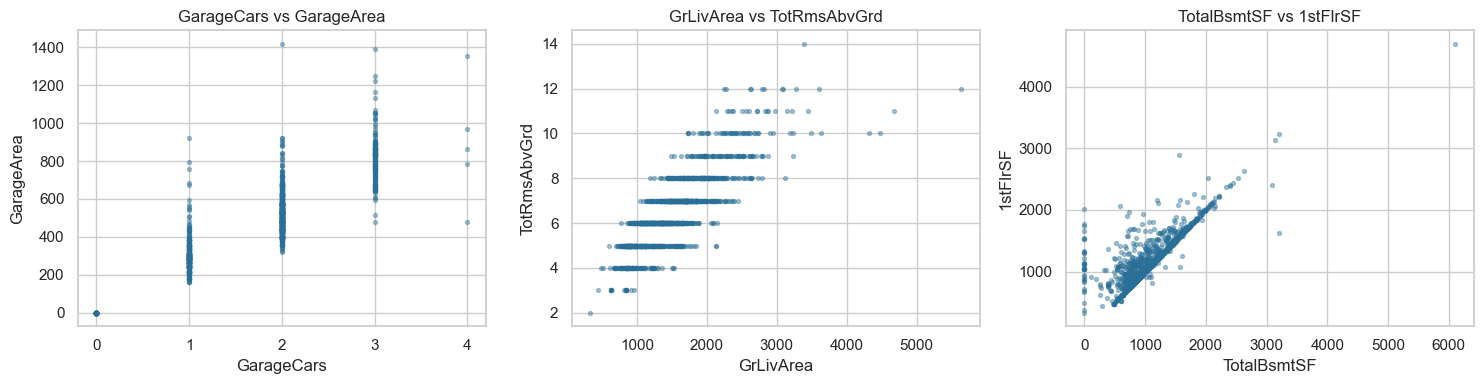

In [120]:
X = num.drop(columns='SalePrice')
cm = X.corr()
iu = np.triu_indices_from(cm, 1)
pairs = pd.DataFrame({'bien_1': cm.columns[iu[0]], 'bien_2': cm.columns[iu[1]], 'r': cm.values[iu]})
strong = pairs[pairs.r.abs() > 0.7].sort_values('r', key=abs, ascending=False).reset_index(drop=True)
print(strong.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax,(a,b) in zip(axes, strong[['bien_1','bien_2']].values):
    ax.scatter(df[a], df[b], s=8, alpha=.4, color='#2a6f97'); ax.set_xlabel(a); ax.set_ylabel(b)
    ax.set_title(f'{a} vs {b}')
plt.tight_layout(); plt.show()

Ba cặp vượt ngưỡng 0.7: `GarageCars` & `GarageArea` (0.88), `GrLivArea` & `TotRmsAbvGrd` (0.83), `TotalBsmtSF` & `1stFlrSF` (0.82). Cả ba đều có lời giải thích vật lý (sức chứa gara do diện tích quyết định, thêm phòng thì diện tích sống tăng, móng tầng một nằm trên tầng hầm).

## 3. Biến phân loại: boxplot và ANOVA

ANOVA kiểm định xem trung bình `log1p(SalePrice)` có khác nhau giữa các nhóm hay không; **eta²** cho biết biến đó giải thích bao nhiêu phần phương sai của giá. Dùng log để kết quả không bị ảnh hưởng bởi đuôi phải của giá nhà.

In [121]:
y = np.log1p(df['SalePrice'])
rows = []
for col in df.select_dtypes(exclude='number').columns:
    groups = [y[idx].values for idx in df.groupby(col).groups.values() if len(idx) > 1]
    if len(groups) < 2: continue
    F, p = stats.f_oneway(*groups)
    ssb = sum(len(g)*(g.mean()-y.mean())**2 for g in groups)
    rows.append((col, F, p, ssb/((y-y.mean())**2).sum()))
anova = pd.DataFrame(rows, columns=['bien','F','p_value','eta2']).sort_values('eta2', ascending=False).reset_index(drop=True)
print(anova.head(10).round(4).to_string())

           bien         F  p_value    eta2
0  Neighborhood   79.5205      0.0  0.5708
1     ExterQual  415.3043      0.0  0.4611
2      BsmtQual  300.3929      0.0  0.4523
3   KitchenQual  393.3209      0.0  0.4476
4  GarageFinish  298.7696      0.0  0.3810
5    GarageType  121.7962      0.0  0.3346
6   FireplaceQu  131.1986      0.0  0.3109
7    Foundation  126.8068      0.0  0.3037
8     HeatingQC  146.6100      0.0  0.2317
9  BsmtFinType1   71.3818      0.0  0.2277


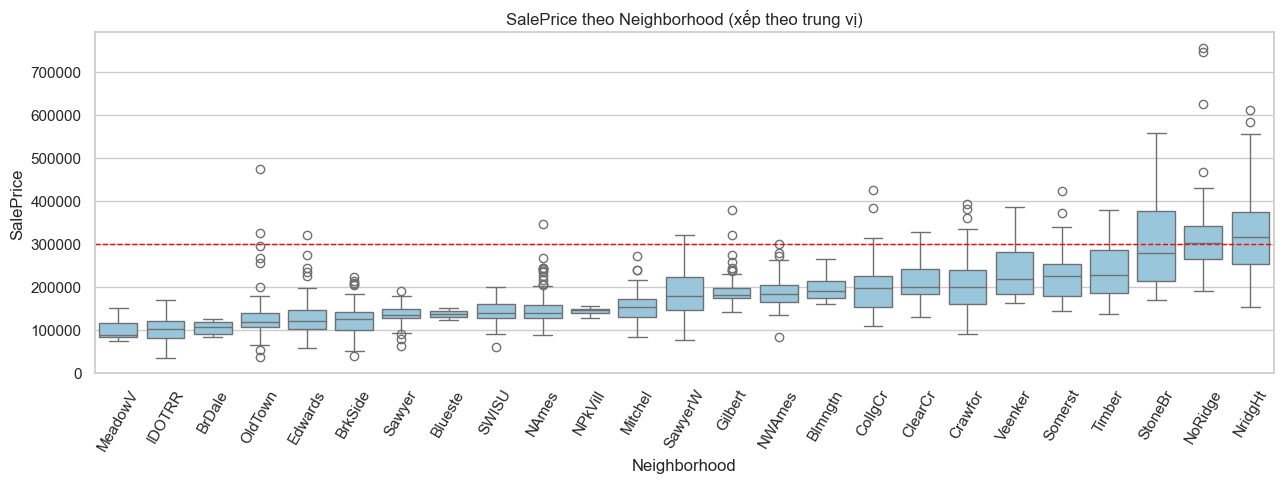

Rẻ nhất : {'MeadowV': 88000.0, 'IDOTRR': 103000.0, 'BrDale': 106000.0}
Đắt nhất: {'StoneBr': 278000.0, 'NoRidge': 301500.0, 'NridgHt': 315000.0}
Độ lệch chuẩn StoneBr = 112970 | MeadowV = 23491


In [122]:
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
fig, ax = plt.subplots(figsize=(13,5))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order, color='#8ecae6', ax=ax)
ax.axhline(300000, ls='--', color='red', lw=1); ax.tick_params(axis='x', rotation=60)
ax.set_title('SalePrice theo Neighborhood (xếp theo trung vị)'); plt.tight_layout(); plt.show()

med = df.groupby('Neighborhood')['SalePrice'].median().sort_values()
sd = df.groupby('Neighborhood')['SalePrice'].std()
print('Rẻ nhất :', med.head(3).round(0).to_dict())
print('Đắt nhất:', med.tail(3).round(0).to_dict())
print('Độ lệch chuẩn StoneBr = %.0f | MeadowV = %.0f' % (sd['StoneBr'], sd['MeadowV']))

`Neighborhood` có eta² cao nhất (≈ 0.57), tức vị trí một mình giải thích hơn một nửa phương sai của log giá. Tiếp theo là `ExterQual`, `BsmtQual`, `KitchenQual` (≈ 0.45), toàn là các biến chất lượng. Boxplot cho thấy các khu `StoneBr`, `NridgHt`, `NoRidge` có trung vị cao hơn hẳn và độ phân tán lớn hơn `MeadowV`, nghĩa là phương sai tăng theo mức giá.

## 4. Chẩn đoán đa cộng tuyến bằng VIF

$$VIF_i = \frac{1}{1-R_i^2}$$

Ngưỡng: VIF > 5 là đáng lo, VIF > 10 là nghiêm trọng. Chạy VIF lần đầu trên toàn bộ biến số (trừ `SalePrice`).

In [123]:
def vif_table(Xdf):
    Xv = Xdf.assign(const=1.0)
    v = [variance_inflation_factor(Xv.values, i) for i in range(Xdf.shape[1])]
    return pd.Series(v, index=Xdf.columns, name='VIF').sort_values(ascending=False)

feats = num.drop(columns='SalePrice')
vif_before = vif_table(feats)
print(vif_before.head(12).map(lambda v: f'{v:,.3g}').to_string())
vif_before.to_csv('vif_before.csv')

BsmtFinSF2       inf
BsmtUnfSF        inf
TotalBsmtSF      inf
GrLivArea        inf
LowQualFinSF     inf
2ndFlrSF         inf
BsmtFinSF1       inf
1stFlrSF         inf
GarageCars      6.07
GarageArea      5.32
TotRmsAbvGrd    4.83
YearBuilt        4.1


Tám biến có VIF cỡ 10¹⁵ (thực chất là vô hạn): đó là **cộng tuyến hoàn hảo**, không phải tương quan mạnh thông thường. Nguyên nhân là hai đẳng thức định nghĩa. Kiểm tra bên dưới:

In [124]:
d1 = (df.TotalBsmtSF - (df.BsmtFinSF1 + df.BsmtFinSF2 + df.BsmtUnfSF)).abs().max()
d2 = (df.GrLivArea - (df['1stFlrSF'] + df['2ndFlrSF'] + df.LowQualFinSF)).abs().max()
print('TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF   -> sai lệch lớn nhất:', d1)
print('GrLivArea   = 1stFlrSF + 2ndFlrSF + LowQualFinSF    -> sai lệch lớn nhất:', d2)

TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF   -> sai lệch lớn nhất: 0
GrLivArea   = 1stFlrSF + 2ndFlrSF + LowQualFinSF    -> sai lệch lớn nhất: 0


Cả hai đẳng thức đúng tuyệt đối trên 1460 dòng, nên mỗi tổng (`TotalBsmtSF`, `GrLivArea`) là tổ hợp tuyến tính chính xác của các thành phần. Với hồi quy OLS, ma trận thiết kế bị suy biến và hệ số không xác định duy nhất.

**Cách xử lý (theo từng bước, có lý do):**
1. Giữ hai biến tổng `TotalBsmtSF`, `GrLivArea` (tương quan với giá mạnh hơn và đã là dạng tổng hợp), loại 6 thành phần: `BsmtFinSF1`, `BsmtFinSF2`, `BsmtUnfSF`, `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF`. Việc này cũng giải quyết luôn cặp `TotalBsmtSF` & `1stFlrSF`.
2. Cặp `GarageCars` & `GarageArea`: giữ `GarageCars` (tương quan với giá cao hơn: 0.64 so với 0.62), loại `GarageArea`.
3. Cặp `GrLivArea` & `TotRmsAbvGrd`: giữ `GrLivArea` (0.71 so với 0.53), loại `TotRmsAbvGrd`.

In [125]:
step1 = ['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','1stFlrSF','2ndFlrSF','LowQualFinSF']
step2 = ['GarageArea']
step3 = ['TotRmsAbvGrd']
drop_log = (
    [(c, {'BsmtFinSF1':'Thành phần của TotalBsmtSF','BsmtFinSF2':'Thành phần của TotalBsmtSF','BsmtUnfSF':'Thành phần của TotalBsmtSF',
          '1stFlrSF':'Thành phần của GrLivArea; còn tương quan 0.82 với TotalBsmtSF',
          '2ndFlrSF':'Thành phần của GrLivArea','LowQualFinSF':'Thành phần của GrLivArea'}[c],
      'Cộng tuyến hoàn hảo (VIF vô hạn)') for c in step1] +
    [(c, 'Giữ GarageCars (r với giá cao hơn)', 'r(GarageCars, GarageArea) = 0.88') for c in step2] +
    [(c, 'Giữ GrLivArea (r với giá cao hơn)', 'r(GrLivArea, TotRmsAbvGrd) = 0.83') for c in step3])
drop_df = pd.DataFrame(drop_log, columns=['bien_loai','ly_do','bang_chung'])
drop_df['corr_voi_SalePrice'] = drop_df.bien_loai.map(corr_target).round(3)
drop_df.to_csv('features_to_drop.csv', index=False)
print(drop_df.to_string(index=False))

feats_clean = feats.drop(columns=drop_df.bien_loai)
vif_after = vif_table(feats_clean)
vif_after.to_csv('vif_after.csv')
print('\nVIF sau xử lý (top 10):'); print(vif_after.head(10).round(2).to_string())
print('\nSố biến còn lại:', feats_clean.shape[1], '| VIF lớn nhất: %.2f' % vif_after.max())

   bien_loai                                                         ly_do                        bang_chung  corr_voi_SalePrice
  BsmtFinSF1                                    Thành phần của TotalBsmtSF  Cộng tuyến hoàn hảo (VIF vô hạn)               0.386
  BsmtFinSF2                                    Thành phần của TotalBsmtSF  Cộng tuyến hoàn hảo (VIF vô hạn)              -0.011
   BsmtUnfSF                                    Thành phần của TotalBsmtSF  Cộng tuyến hoàn hảo (VIF vô hạn)               0.214
    1stFlrSF Thành phần của GrLivArea; còn tương quan 0.82 với TotalBsmtSF  Cộng tuyến hoàn hảo (VIF vô hạn)               0.606
    2ndFlrSF                                      Thành phần của GrLivArea  Cộng tuyến hoàn hảo (VIF vô hạn)               0.319
LowQualFinSF                                      Thành phần của GrLivArea  Cộng tuyến hoàn hảo (VIF vô hạn)              -0.026
  GarageArea                            Giữ GarageCars (r với giá cao hơn)  r(GarageCars, GarageA

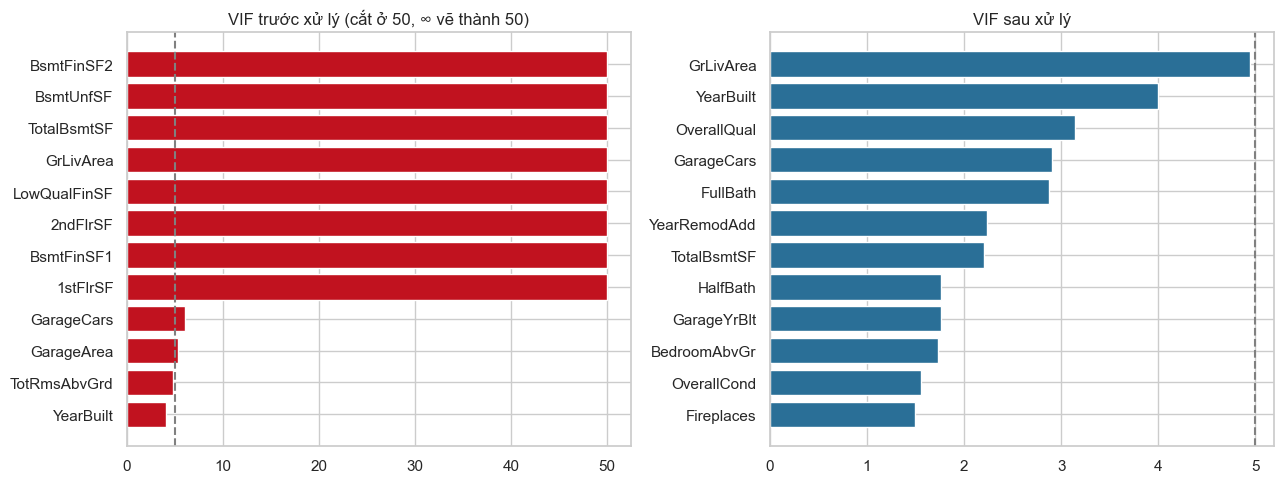

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
b = vif_before.clip(upper=50).head(12)[::-1]; a = vif_after.head(12)[::-1]
axes[0].barh(b.index, b.values, color='#c1121f'); axes[0].set_title('VIF trước xử lý (cắt ở 50, ∞ vẽ thành 50)')
axes[1].barh(a.index, a.values, color='#2a6f97'); axes[1].set_title('VIF sau xử lý')
for ax in axes: ax.axvline(5, ls='--', color='gray')
plt.tight_layout(); plt.show()

## 5. Kết luận

- **Yếu tố mạnh nhất**: `OverallQual` (0.79), `GrLivArea` (0.71), nhóm gara và tầng hầm (0.61 đến 0.64). Với biến phân loại: `Neighborhood` (eta² ≈ 0.57), rồi `ExterQual`, `BsmtQual`, `KitchenQual`.
- **Đa cộng tuyến**: có hai loại. Loại nghiêm trọng là cộng tuyến hoàn hảo do các biến diện tích gốc là thành phần của các biến tổng (6 biến). Loại thứ hai là ba cặp song sinh tương quan 0.82 đến 0.88.
- **Đề xuất**: loại 8 biến trong `features_to_drop.csv`. Sau đó mọi biến số đều có VIF < 5 (lớn nhất là `GrLivArea` = 4.94, sát ngưỡng), không cần xử lý thêm trước khi đưa vào Ridge/Lasso.
- **Giới hạn**: VIF và Pearson chỉ đo quan hệ tuyến tính giữa biến số; mô hình cây (XGBoost, LightGBM) ít nhạy với đa cộng tuyến nên việc loại biến chủ yếu phục vụ nhóm mô hình tuyến tính.

##  Phân loại biến

In [127]:
ID_COL = 'Id'
TARGET = 'SalePrice'

discrete_cols = [
    'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MoSold', 'YrSold',
    'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',
]

continuous_cols = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
    'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
    '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', TARGET,
]

ordinal_cols = [
    'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual',
    'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'LotShape',
    'LandSlope', 'Utilities', 'Functional', 'GarageFinish', 'PavedDrive',
]

assigned = {ID_COL, *discrete_cols, *continuous_cols, *ordinal_cols}
nominal_cols = [c for c in train.columns if c not in assigned]

groups = {
    'Số – rời rạc': discrete_cols,
    'Số – liên tục': continuous_cols,
    'Phân loại – thứ tự': ordinal_cols,
    'Phân loại – danh nghĩa': nominal_cols,
}

all_assigned = [ID_COL] + discrete_cols + continuous_cols + ordinal_cols + nominal_cols
assert len(all_assigned) == len(set(all_assigned)), 'Có cột bị gán trùng nhóm'
assert set(all_assigned) == set(train.columns), 'Có cột chưa được phân nhóm'

col2group = {ID_COL: 'Định danh (Id)'}
for g, cols in groups.items():
    for c in cols:
        col2group[c] = g

for g, cols in groups.items():
    print(f'\n[{g}] ({len(cols)} cột):\n  ', ', '.join(cols))


[Số – rời rạc] (14 cột):
   YearBuilt, YearRemodAdd, GarageYrBlt, MoSold, YrSold, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, TotRmsAbvGrd, Fireplaces, GarageCars

[Số – liên tục] (20 cột):
   LotFrontage, LotArea, MasVnrArea, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, GarageArea, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, MiscVal, SalePrice

[Phân loại – thứ tự] (22 cột):
   OverallQual, OverallCond, ExterQual, ExterCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, HeatingQC, KitchenQual, FireplaceQu, GarageQual, GarageCond, PoolQC, Fence, LotShape, LandSlope, Utilities, Functional, GarageFinish, PavedDrive

[Phân loại – danh nghĩa] (24 cột):
   MSSubClass, MSZoning, Street, Alley, LandContour, LotConfig, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, Foundation, Heating, CentralAir, 

##  Báo cáo tỷ lệ dữ liệu khuyết

In [128]:
def missing_report(df, name):
    n = len(df)
    rep = pd.DataFrame({'Số dòng khuyết': df.isnull().sum()})
    rep['Tỷ lệ khuyết (%)'] = (rep['Số dòng khuyết'] / n * 100).round(2)
    rep = rep[rep['Số dòng khuyết'] > 0].sort_values('Tỷ lệ khuyết (%)', ascending=False)
    total = df.size
    print(f'[{name}] {len(rep)}/{df.shape[1]} cột có khuyết | '
          f'{int(df.isnull().sum().sum())} ô khuyết ({df.isnull().sum().sum()/total*100:.2f}% tổng số ô)')
    return rep

report_train = missing_report(train_raw, 'TRAIN')

[TRAIN] 19/81 cột có khuyết | 7829 ô khuyết (6.62% tổng số ô)


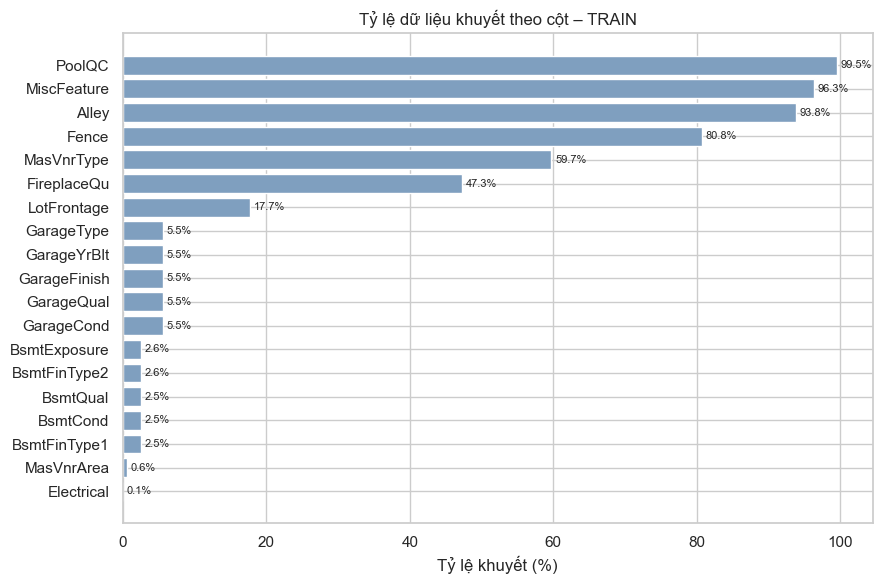

In [129]:
KEY = ['PoolQC', 'Alley', 'Fence', 'FireplaceQu']

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = report_train.reset_index().rename(columns={'index': 'Cột'})
ax.barh(plot_df['Cột'], plot_df['Tỷ lệ khuyết (%)'], color='#7f9fbf')
ax.invert_yaxis()
ax.set_xlabel('Tỷ lệ khuyết (%)')
ax.set_title('Tỷ lệ dữ liệu khuyết theo cột – TRAIN')
for i, v in enumerate(plot_df['Tỷ lệ khuyết (%)']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()

In [130]:
report_test = missing_report(test_raw, 'TEST')

[TEST] 33/80 cột có khuyết | 7878 ô khuyết (6.75% tổng số ô)


##  Điền khuyết

In [131]:
STRUCTURES = {
    'Hồ bơi': (['PoolQC'], ['PoolArea'],
               lambda d: d['PoolArea'].fillna(0) > 0),
    'Tầng hầm': (['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'],
                 ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'],
                 lambda d: d['TotalBsmtSF'].fillna(0) > 0),
    'Gara': (['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'],
             ['GarageCars', 'GarageArea', 'GarageYrBlt'],
             lambda d: d['GarageType'].notna() | (d['GarageArea'].fillna(0) > 0)),
    'Lò sưởi': (['FireplaceQu'], [],
                lambda d: d['Fireplaces'].fillna(0) > 0),
    'Ốp gạch/đá': ([], ['MasVnrArea'],
                   lambda d: d['MasVnrArea'].fillna(0) > 0),
    'Tiện ích khác': (['MiscFeature'], [],
                      lambda d: d['MiscVal'].fillna(0) > 0),
}

ALWAYS_NONE = ['Alley', 'Fence', 'MasVnrType']

def fit_fill_values(ref):
    vals = {}
    for name, (cat, num, has) in STRUCTURES.items():
        mask = has(ref)
        for c in cat:
            s = ref.loc[mask, c].dropna()
            vals[c] = s.mode()[0] if len(s) else 'None'
        for c in num:
            s = ref.loc[mask, c].dropna()
            vals[c] = s.median() if len(s) else 0
    return vals

fill_values = fit_fill_values(train_raw)

def impute_structural(df):
    df = df.copy()
    masks = {name: has(df) for name, (_, _, has) in STRUCTURES.items()}
    for name, (cat, num, _) in STRUCTURES.items():
        present = masks[name]
        for c in cat:
            na = df[c].isna()
            df.loc[na & ~present, c] = 'None'
            df.loc[na & present, c] = fill_values[c]
        for c in num:
            na = df[c].isna()
            df.loc[na & ~present, c] = 0
            if c == 'GarageYrBlt':
                df.loc[na & present, c] = df.loc[na & present, 'YearBuilt']
            else:
                df.loc[na & present, c] = fill_values[c]
    for c in ALWAYS_NONE:
        df[c] = df[c].fillna('None')
    return df

train = impute_structural(train)
test = impute_structural(test)

### Khuyết ngẫu nhiên còn lại

In [132]:
RANDOM_CAT = ['Electrical', 'MSZoning', 'Utilities', 'Functional', 'Exterior1st',
              'Exterior2nd', 'KitchenQual', 'SaleType']

for c in RANDOM_CAT:
    mode_val = train_raw[c].mode()[0]
    for d in (train, test):
        d[c] = d[c].fillna(mode_val)

for d, nm in ((train, 'train'), (test, 'test')):
    for c in d.columns:
        if c in ('LotFrontage', TARGET) or not d[c].isna().any():
            continue
        fill = train_raw[c].median() if pd.api.types.is_numeric_dtype(d[c]) else train_raw[c].mode()[0]
        print(f'[safety-net] {nm}.{c}: {d[c].isna().sum()} ô → {fill}')
        d[c] = d[c].fillna(fill)

print('Còn khuyết sau bước này:')
print('  train:', train.drop(columns='LotFrontage').isna().sum().sum(),
      '| test:', test.drop(columns='LotFrontage').isna().sum().sum())

Còn khuyết sau bước này:
  train: 0 | test: 0


##  Nội suy LotFrontage theo Neighborhood

In [133]:
lf_median_by_nb = train_raw.groupby('Neighborhood')['LotFrontage'].median()
lf_global_median = train_raw['LotFrontage'].median()

def impute_lotfrontage(df):
    df = df.copy()
    before = int(df['LotFrontage'].isna().sum())
    df['LotFrontage'] = df['LotFrontage'].fillna(df['Neighborhood'].map(lf_median_by_nb))
    fallback = int(df['LotFrontage'].isna().sum())
    df['LotFrontage'] = df['LotFrontage'].fillna(lf_global_median)
    print(f'  khuyết ban đầu: {before} | điền theo Neighborhood: {before - fallback} | '
          f'dự phòng bằng median toàn cục: {fallback}')
    return df

print('TRAIN'); train = impute_lotfrontage(train)
print('TEST');  test  = impute_lotfrontage(test)

print(f"\nLotFrontage train – trước: mean={train_raw['LotFrontage'].mean():.2f}, "
      f"median={train_raw['LotFrontage'].median():.2f} | sau: mean={train['LotFrontage'].mean():.2f}, "
      f"median={train['LotFrontage'].median():.2f}")

TRAIN
  khuyết ban đầu: 0 | điền theo Neighborhood: 0 | dự phòng bằng median toàn cục: 0
TEST
  khuyết ban đầu: 0 | điền theo Neighborhood: 0 | dự phòng bằng median toàn cục: 0

LotFrontage train – trước: mean=70.05, median=69.00 | sau: mean=70.20, median=70.00


##  Kiểm tra đầu ra

In [134]:
na_train, na_test = int(train.isna().sum().sum()), int(test.isna().sum().sum())
print(f'NaN train: {na_train} | NaN test: {na_test}')
print(f'Shape train: {train.shape} | test: {test.shape}')
assert na_train == 0 and na_test == 0
assert train.shape == train_raw.shape and test.shape == test_raw.shape
assert (train['Id'].values == train_raw['Id'].values).all()

NaN train: 0 | NaN test: 0
Shape train: (1460, 81) | test: (1459, 80)


In [135]:
train.to_csv('Data/train_filled.csv', index=False)
test.to_csv('Data/test_filled.csv', index=False)

chk_tr = pd.read_csv('Data/train_filled.csv', keep_default_na=False, na_values=[''])
chk_te = pd.read_csv('Data/test_filled.csv',  keep_default_na=False, na_values=[''])
print('Nạp lại → NaN train:', chk_tr.isna().sum().sum(), '| NaN test:', chk_te.isna().sum().sum())

Nạp lại → NaN train: 0 | NaN test: 0


##  Feature Engineering

In [136]:
train_fe, test_fe = train.copy(), test.copy()

def add_features(d):
    d['TotalSF']      = d['TotalBsmtSF'] + d['1stFlrSF'] + d['2ndFlrSF']
    d['HouseAge']     = d['YrSold'] - d['YearBuilt']
    d['RemodAge']     = d['YrSold'] - d['YearRemodAdd']
    d['TotalBath']    = d['FullBath'] + 0.5 * d['HalfBath'] + d['BsmtFullBath'] + 0.5 * d['BsmtHalfBath']
    d['HasGarage']    = (d['GarageArea'] > 0).astype(int)
    d['HasBsmt']      = (d['TotalBsmtSF'] > 0).astype(int)
    d['HasFireplace'] = (d['Fireplaces'] > 0).astype(int)
    d['Has2ndFloor']  = (d['2ndFlrSF'] > 0).astype(int)
    d['TotalPorchSF'] = (d['OpenPorchSF'] + d['3SsnPorch'] + d['EnclosedPorch']
                         + d['ScreenPorch'] + d['WoodDeckSF'])
    return d

train_fe, test_fe = add_features(train_fe), add_features(test_fe)

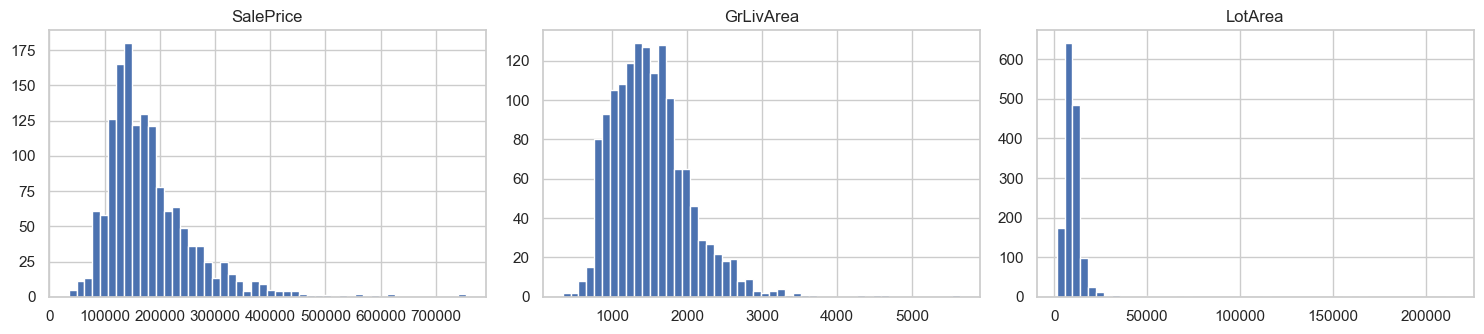

In [137]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, ['SalePrice', 'GrLivArea', 'LotArea']):
    train_fe[col].hist(bins=50, ax=ax); ax.set_title(col)
plt.tight_layout(); plt.show()

In [138]:
log_features = ['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'BsmtFinSF2',
                'ScreenPorch', 'EnclosedPorch', 'MasVnrArea', 'LotFrontage', 'OpenPorchSF',
                'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'TotalSF']

for col in log_features:
    train_fe[col] = np.log1p(train_fe[col])
    test_fe[col]  = np.log1p(test_fe[col])

In [139]:
print('Cột chỉ có ở train:', set(train_fe.columns) - set(test_fe.columns))
print('Cột chỉ có ở test :', set(test_fe.columns) - set(train_fe.columns))
print('Train shape:', train_fe.shape, '| Test shape:', test_fe.shape)
print('NaN train_fe:', train_fe.isna().sum().sum(), '| NaN test_fe:', test_fe.isna().sum().sum())
assert train_fe.isna().sum().sum() == 0 and test_fe.isna().sum().sum() == 0

train_fe.to_csv('Data/train_fe.csv', index=False)
test_fe.to_csv('Data/test_fe.csv', index=False)

Cột chỉ có ở train: {'SalePrice'}
Cột chỉ có ở test : set()
Train shape: (1460, 90) | Test shape: (1459, 89)
NaN train_fe: 0 | NaN test_fe: 0


# Phân tích đa biến và chẩn đoán đa cộng tuyến (Ames Housing)

**Nhiệm vụ**
- Xây dựng ma trận tương quan Pearson giữa các biến số và `SalePrice`, xếp hạng yếu tố có sức dự báo mạnh nhất.
- Với biến phân loại: dùng boxplot và ANOVA (kèm eta²) để đo mức ảnh hưởng, lấy `Neighborhood` làm ví dụ chính.
- Phát hiện các "cặp biến song sinh" (tương quan chặt giữa các biến độc lập).
- Tính VIF, xác định biến dư thừa, đề xuất danh sách biến loại bỏ.

**Đầu ra**: bảng xếp hạng tương quan, các biểu đồ, bảng VIF trước và sau xử lý, danh sách biến cần loại (`features_to_drop.csv`, `vif_before.csv`, `vif_after.csv`).

**Đầu vào hiện tại**: `train.csv` của Kaggle (1460 dòng, 81 cột)

In [140]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
%matplotlib inline
sns.set_theme(style='whitegrid')

df = pd.read_csv('Data/train.csv')

# --- Điền khuyết rút gọn ---
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu','GarageType','GarageFinish',
             'GarageQual','GarageCond','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
             'BsmtFinType2','MasVnrType']
for c in none_cols: df[c] = df[c].fillna('None')
for c in ['GarageYrBlt','MasVnrArea']: df[c] = df[c].fillna(0)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda s: s.fillna(s.median()))
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
print(df.shape, '| NaN còn lại:', df.isna().sum().sum())

(1460, 81) | NaN còn lại: 0


##  Tương quan Pearson với SalePrice

`MSSubClass` là mã loại nhà (10, 20, 30, ...) nên thực chất là biến danh nghĩa, được tách ra khỏi nhóm biến số. `Id` chỉ là chỉ số dòng nên bỏ.

OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507


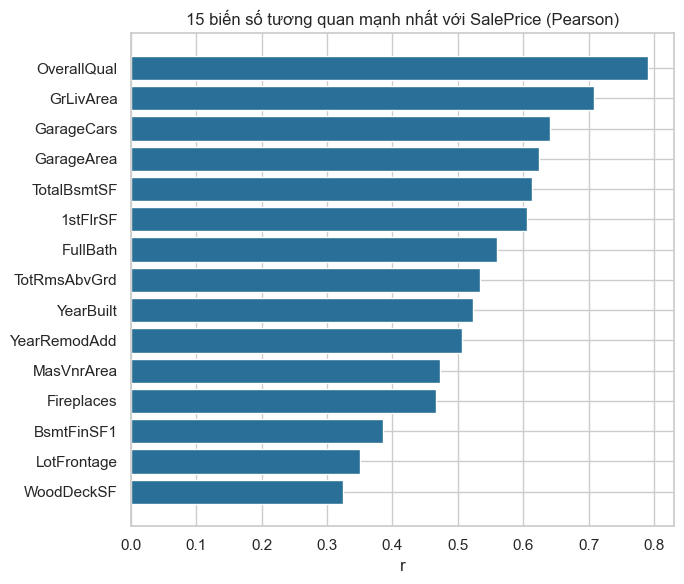

In [141]:
num = df.select_dtypes('number').drop(columns=['Id','MSSubClass'])
corr_target = num.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print(corr_target.head(10).round(3).to_string())

fig, ax = plt.subplots(figsize=(7,6))
top = corr_target.head(15)[::-1]
ax.barh(top.index, top.values, color='#2a6f97')
ax.set_title('15 biến số tương quan mạnh nhất với SalePrice (Pearson)')
ax.set_xlabel('r'); plt.tight_layout(); plt.show()

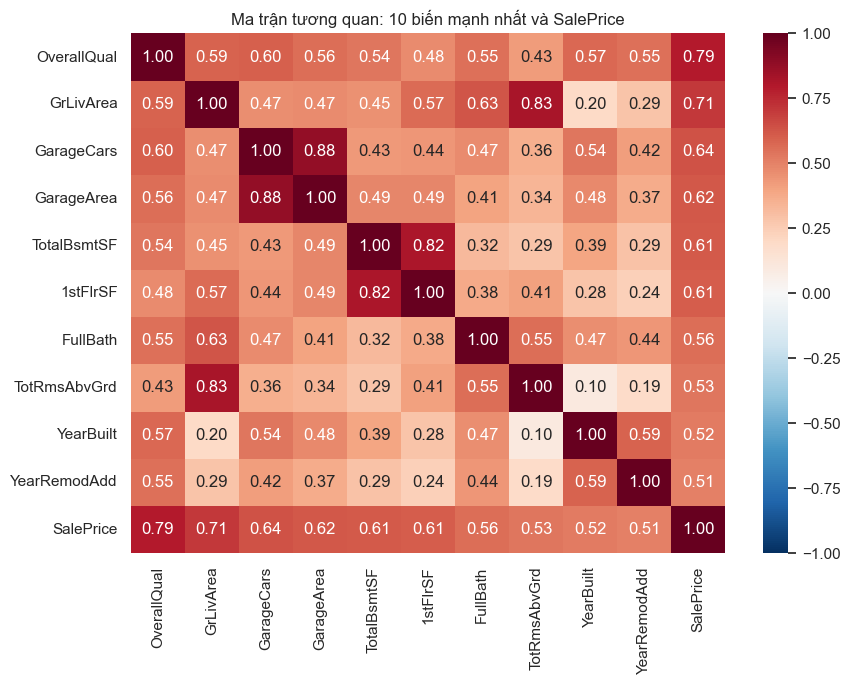

In [142]:
top10 = corr_target.head(10).index.tolist() + ['SalePrice']
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(num[top10].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Ma trận tương quan: 10 biến mạnh nhất và SalePrice')
plt.tight_layout(); plt.show()

**Nhận xét**: `OverallQual` dẫn đầu (r ≈ 0.79), sau đó là các biến diện tích và gara: `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62), `TotalBsmtSF` (0.61). Các số này khớp với phần 5 của báo cáo. Trong heatmap cũng thấy ngay các ô đậm giữa những biến độc lập với nhau (gara, tầng hầm, diện tích sống), đó là dấu hiệu đa cộng tuyến cần kiểm tra ở mục 3.

##  Các cặp biến độc lập tương quan chặt

        bien_1        bien_2      r
0   GarageCars    GarageArea  0.882
1    GrLivArea  TotRmsAbvGrd  0.825
2  TotalBsmtSF      1stFlrSF  0.820


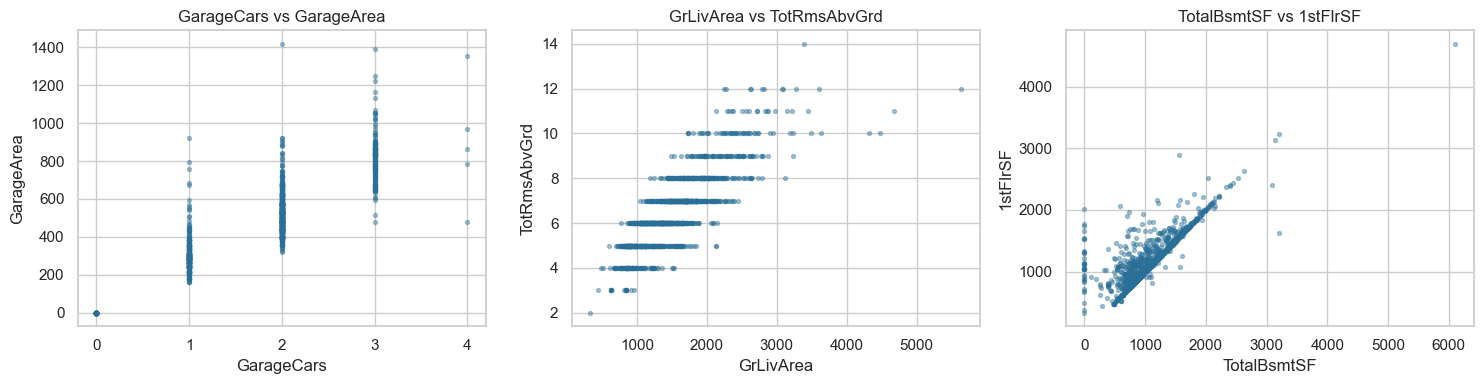

In [143]:
X = num.drop(columns='SalePrice')
cm = X.corr()
iu = np.triu_indices_from(cm, 1)
pairs = pd.DataFrame({'bien_1': cm.columns[iu[0]], 'bien_2': cm.columns[iu[1]], 'r': cm.values[iu]})
strong = pairs[pairs.r.abs() > 0.7].sort_values('r', key=abs, ascending=False).reset_index(drop=True)
print(strong.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax,(a,b) in zip(axes, strong[['bien_1','bien_2']].values):
    ax.scatter(df[a], df[b], s=8, alpha=.4, color='#2a6f97'); ax.set_xlabel(a); ax.set_ylabel(b)
    ax.set_title(f'{a} vs {b}')
plt.tight_layout(); plt.show()

Ba cặp vượt ngưỡng 0.7: `GarageCars` & `GarageArea` (0.88), `GrLivArea` & `TotRmsAbvGrd` (0.83), `TotalBsmtSF` & `1stFlrSF` (0.82). Cả ba đều có lời giải thích vật lý (sức chứa gara do diện tích quyết định, thêm phòng thì diện tích sống tăng, móng tầng một nằm trên tầng hầm).

##  Biến phân loại: boxplot và ANOVA

ANOVA kiểm định xem trung bình `log1p(SalePrice)` có khác nhau giữa các nhóm hay không; **eta²** cho biết biến đó giải thích bao nhiêu phần phương sai của giá. Dùng log để kết quả không bị ảnh hưởng bởi đuôi phải của giá nhà.

In [144]:
y = np.log1p(df['SalePrice'])
rows = []
for col in df.select_dtypes(exclude='number').columns:
    groups = [y[idx].values for idx in df.groupby(col).groups.values() if len(idx) > 1]
    if len(groups) < 2: continue
    F, p = stats.f_oneway(*groups)
    ssb = sum(len(g)*(g.mean()-y.mean())**2 for g in groups)
    rows.append((col, F, p, ssb/((y-y.mean())**2).sum()))
anova = pd.DataFrame(rows, columns=['bien','F','p_value','eta2']).sort_values('eta2', ascending=False).reset_index(drop=True)
print(anova.head(10).round(4).to_string())

           bien         F  p_value    eta2
0  Neighborhood   79.5205      0.0  0.5708
1     ExterQual  415.3043      0.0  0.4611
2      BsmtQual  300.3929      0.0  0.4523
3   KitchenQual  393.3209      0.0  0.4476
4  GarageFinish  298.7696      0.0  0.3810
5    GarageType  121.7962      0.0  0.3346
6   FireplaceQu  131.1986      0.0  0.3109
7    Foundation  126.8068      0.0  0.3037
8     HeatingQC  146.6100      0.0  0.2317
9  BsmtFinType1   71.3818      0.0  0.2277


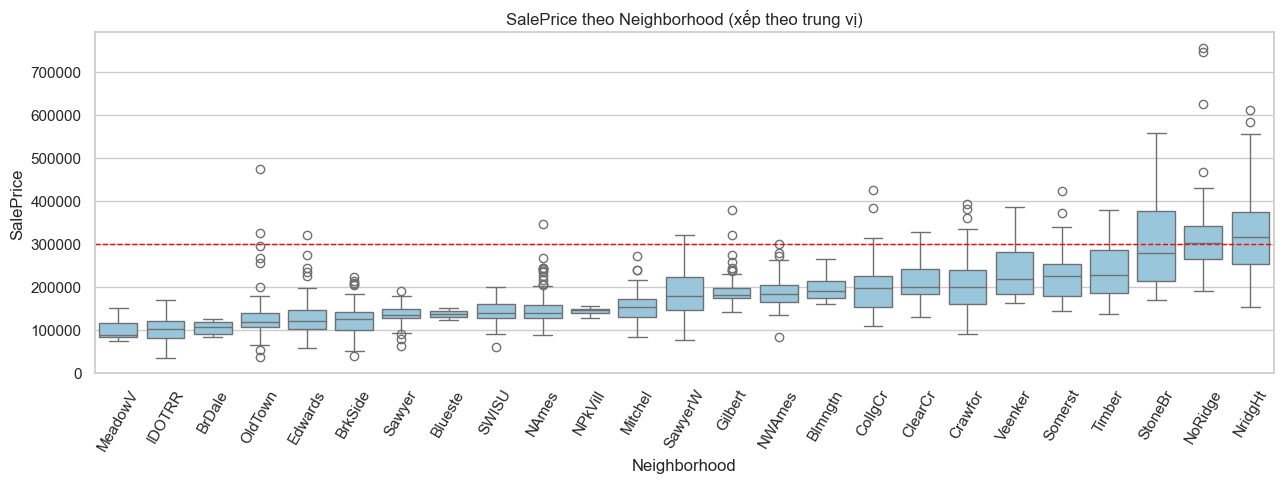

Rẻ nhất : {'MeadowV': 88000.0, 'IDOTRR': 103000.0, 'BrDale': 106000.0}
Đắt nhất: {'StoneBr': 278000.0, 'NoRidge': 301500.0, 'NridgHt': 315000.0}
Độ lệch chuẩn StoneBr = 112970 | MeadowV = 23491


In [145]:
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
fig, ax = plt.subplots(figsize=(13,5))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order, color='#8ecae6', ax=ax)
ax.axhline(300000, ls='--', color='red', lw=1); ax.tick_params(axis='x', rotation=60)
ax.set_title('SalePrice theo Neighborhood (xếp theo trung vị)'); plt.tight_layout(); plt.show()

med = df.groupby('Neighborhood')['SalePrice'].median().sort_values()
sd = df.groupby('Neighborhood')['SalePrice'].std()
print('Rẻ nhất :', med.head(3).round(0).to_dict())
print('Đắt nhất:', med.tail(3).round(0).to_dict())
print('Độ lệch chuẩn StoneBr = %.0f | MeadowV = %.0f' % (sd['StoneBr'], sd['MeadowV']))

`Neighborhood` có eta² cao nhất (≈ 0.57), tức vị trí một mình giải thích hơn một nửa phương sai của log giá. Tiếp theo là `ExterQual`, `BsmtQual`, `KitchenQual` (≈ 0.45), toàn là các biến chất lượng. Boxplot cho thấy các khu `StoneBr`, `NridgHt`, `NoRidge` có trung vị cao hơn hẳn và độ phân tán lớn hơn `MeadowV`, nghĩa là phương sai tăng theo mức giá.

##  Chẩn đoán đa cộng tuyến bằng VIF

$$VIF_i = \frac{1}{1-R_i^2}$$

Ngưỡng: VIF > 5 là đáng lo, VIF > 10 là nghiêm trọng. Chạy VIF lần đầu trên toàn bộ biến số (trừ `SalePrice`).

In [146]:
def vif_table(Xdf):
    Xv = Xdf.assign(const=1.0)
    v = [variance_inflation_factor(Xv.values, i) for i in range(Xdf.shape[1])]
    return pd.Series(v, index=Xdf.columns, name='VIF').sort_values(ascending=False)

feats = num.drop(columns='SalePrice')
vif_before = vif_table(feats)
print(vif_before.head(12).map(lambda v: f'{v:,.3g}').to_string())
vif_before.to_csv('vif_before.csv')

BsmtFinSF2       inf
BsmtUnfSF        inf
TotalBsmtSF      inf
GrLivArea        inf
LowQualFinSF     inf
2ndFlrSF         inf
BsmtFinSF1       inf
1stFlrSF         inf
GarageCars      6.07
GarageArea      5.32
TotRmsAbvGrd    4.83
YearBuilt        4.1


Tám biến có VIF cỡ 10¹⁵ (thực chất là vô hạn): đó là **cộng tuyến hoàn hảo**, không phải tương quan mạnh thông thường. Nguyên nhân là hai đẳng thức định nghĩa. Kiểm tra bên dưới:

In [147]:
d1 = (df.TotalBsmtSF - (df.BsmtFinSF1 + df.BsmtFinSF2 + df.BsmtUnfSF)).abs().max()
d2 = (df.GrLivArea - (df['1stFlrSF'] + df['2ndFlrSF'] + df.LowQualFinSF)).abs().max()
print('TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF   -> sai lệch lớn nhất:', d1)
print('GrLivArea   = 1stFlrSF + 2ndFlrSF + LowQualFinSF    -> sai lệch lớn nhất:', d2)

TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF   -> sai lệch lớn nhất: 0
GrLivArea   = 1stFlrSF + 2ndFlrSF + LowQualFinSF    -> sai lệch lớn nhất: 0


Cả hai đẳng thức đúng tuyệt đối trên 1460 dòng, nên mỗi tổng (`TotalBsmtSF`, `GrLivArea`) là tổ hợp tuyến tính chính xác của các thành phần. Với hồi quy OLS, ma trận thiết kế bị suy biến và hệ số không xác định duy nhất.

**Cách xử lý (theo từng bước, có lý do):**
1. Giữ hai biến tổng `TotalBsmtSF`, `GrLivArea` (tương quan với giá mạnh hơn và đã là dạng tổng hợp), loại 6 thành phần: `BsmtFinSF1`, `BsmtFinSF2`, `BsmtUnfSF`, `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF`. Việc này cũng giải quyết luôn cặp `TotalBsmtSF` & `1stFlrSF`.
2. Cặp `GarageCars` & `GarageArea`: giữ `GarageCars` (tương quan với giá cao hơn: 0.64 so với 0.62), loại `GarageArea`.
3. Cặp `GrLivArea` & `TotRmsAbvGrd`: giữ `GrLivArea` (0.71 so với 0.53), loại `TotRmsAbvGrd`.

In [148]:
step1 = ['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','1stFlrSF','2ndFlrSF','LowQualFinSF']
step2 = ['GarageArea']
step3 = ['TotRmsAbvGrd']
drop_log = (
    [(c, {'BsmtFinSF1':'Thành phần của TotalBsmtSF','BsmtFinSF2':'Thành phần của TotalBsmtSF','BsmtUnfSF':'Thành phần của TotalBsmtSF',
          '1stFlrSF':'Thành phần của GrLivArea; còn tương quan 0.82 với TotalBsmtSF',
          '2ndFlrSF':'Thành phần của GrLivArea','LowQualFinSF':'Thành phần của GrLivArea'}[c],
      'Cộng tuyến hoàn hảo (VIF vô hạn)') for c in step1] +
    [(c, 'Giữ GarageCars (r với giá cao hơn)', 'r(GarageCars, GarageArea) = 0.88') for c in step2] +
    [(c, 'Giữ GrLivArea (r với giá cao hơn)', 'r(GrLivArea, TotRmsAbvGrd) = 0.83') for c in step3])
drop_df = pd.DataFrame(drop_log, columns=['bien_loai','ly_do','bang_chung'])
drop_df['corr_voi_SalePrice'] = drop_df.bien_loai.map(corr_target).round(3)
drop_df.to_csv('features_to_drop.csv', index=False)
print(drop_df.to_string(index=False))

feats_clean = feats.drop(columns=drop_df.bien_loai)
vif_after = vif_table(feats_clean)
vif_after.to_csv('vif_after.csv')
print('\nVIF sau xử lý (top 10):'); print(vif_after.head(10).round(2).to_string())
print('\nSố biến còn lại:', feats_clean.shape[1], '| VIF lớn nhất: %.2f' % vif_after.max())

   bien_loai                                                         ly_do                        bang_chung  corr_voi_SalePrice
  BsmtFinSF1                                    Thành phần của TotalBsmtSF  Cộng tuyến hoàn hảo (VIF vô hạn)               0.386
  BsmtFinSF2                                    Thành phần của TotalBsmtSF  Cộng tuyến hoàn hảo (VIF vô hạn)              -0.011
   BsmtUnfSF                                    Thành phần của TotalBsmtSF  Cộng tuyến hoàn hảo (VIF vô hạn)               0.214
    1stFlrSF Thành phần của GrLivArea; còn tương quan 0.82 với TotalBsmtSF  Cộng tuyến hoàn hảo (VIF vô hạn)               0.606
    2ndFlrSF                                      Thành phần của GrLivArea  Cộng tuyến hoàn hảo (VIF vô hạn)               0.319
LowQualFinSF                                      Thành phần của GrLivArea  Cộng tuyến hoàn hảo (VIF vô hạn)              -0.026
  GarageArea                            Giữ GarageCars (r với giá cao hơn)  r(GarageCars, GarageA

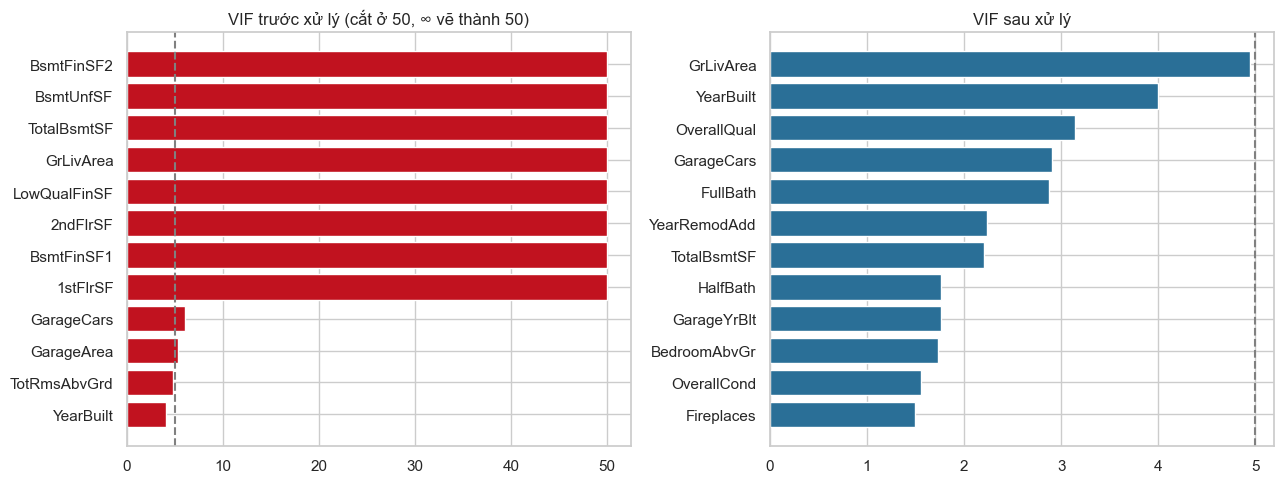

In [149]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
b = vif_before.clip(upper=50).head(12)[::-1]; a = vif_after.head(12)[::-1]
axes[0].barh(b.index, b.values, color='#c1121f'); axes[0].set_title('VIF trước xử lý (cắt ở 50, ∞ vẽ thành 50)')
axes[1].barh(a.index, a.values, color='#2a6f97'); axes[1].set_title('VIF sau xử lý')
for ax in axes: ax.axvline(5, ls='--', color='gray')
plt.tight_layout(); plt.show()

##  Kết luận

- **Yếu tố mạnh nhất**: `OverallQual` (0.79), `GrLivArea` (0.71), nhóm gara và tầng hầm (0.61 đến 0.64). Với biến phân loại: `Neighborhood` (eta² ≈ 0.57), rồi `ExterQual`, `BsmtQual`, `KitchenQual`.
- **Đa cộng tuyến**: có hai loại. Loại nghiêm trọng là cộng tuyến hoàn hảo do các biến diện tích gốc là thành phần của các biến tổng (6 biến). Loại thứ hai là ba cặp song sinh tương quan 0.82 đến 0.88.
- **Đề xuất**: loại 8 biến trong `features_to_drop.csv`. Sau đó mọi biến số đều có VIF < 5 (lớn nhất là `GrLivArea` = 4.94, sát ngưỡng), không cần xử lý thêm trước khi đưa vào Ridge/Lasso.
- **Giới hạn**: VIF và Pearson chỉ đo quan hệ tuyến tính giữa biến số; mô hình cây (XGBoost, LightGBM) ít nhạy với đa cộng tuyến nên việc loại biến chủ yếu phục vụ nhóm mô hình tuyến tính.